<a href="https://colab.research.google.com/github/shounik1904-crypto/Decision-Trees-for-Classification/blob/main/ML_PROJECT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ORIGINAL DECISION TREE RESULTS
Accuracy: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



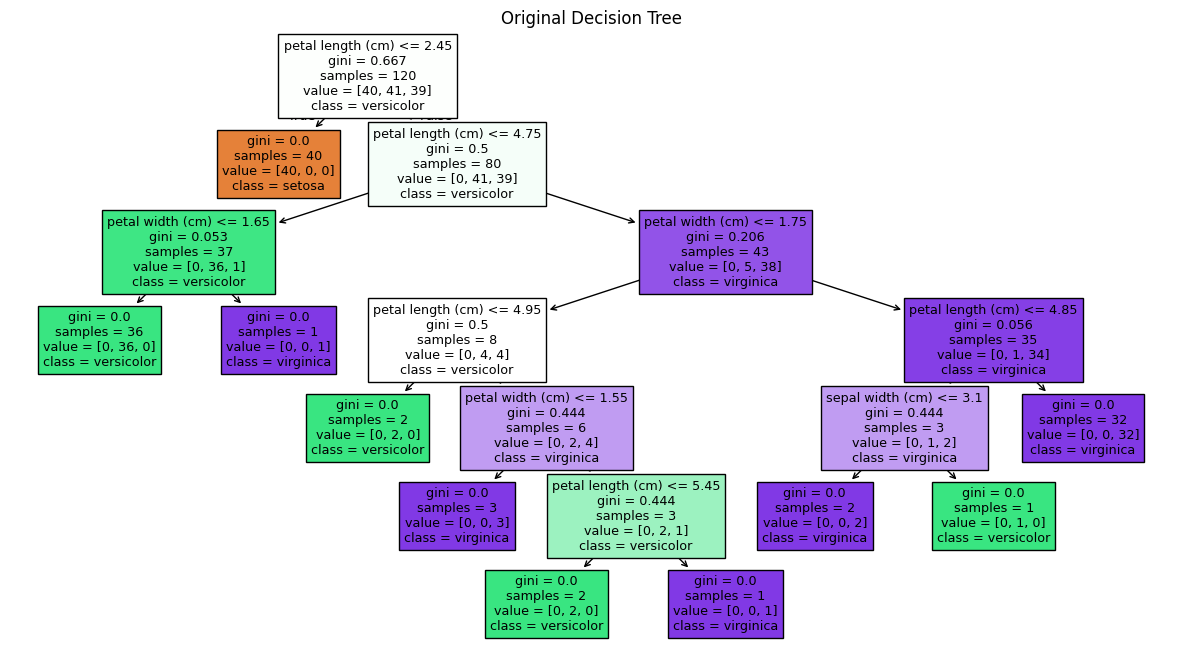

PRUNED DECISION TREE RESULTS
Accuracy: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



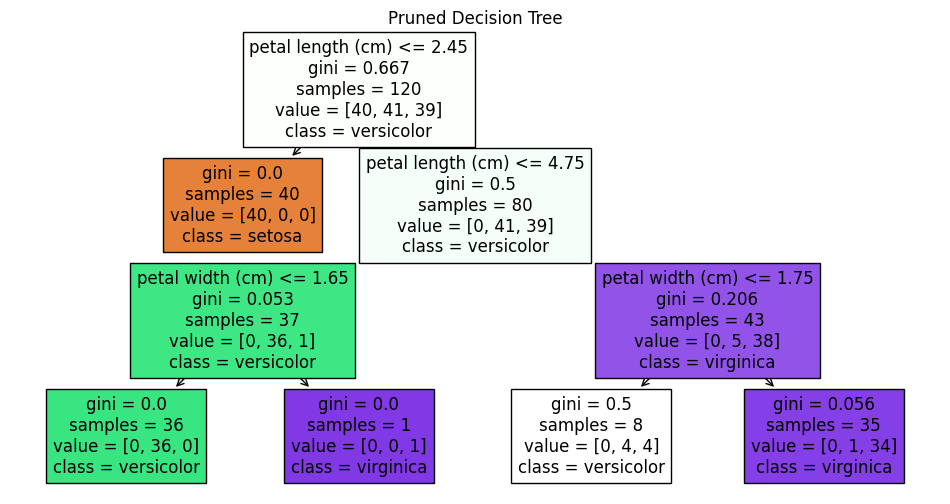

MODEL COMPARISON
           Model  Accuracy  F1 Score
0  Original Tree       1.0       1.0
1    Pruned Tree       1.0       1.0


In [1]:
# Decision Tree Classification on Iris Dataset

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Original Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("ORIGINAL DECISION TREE RESULTS")
print("="*60)
print("Accuracy:", round(accuracy,4))
print("F1 Score:", round(f1,4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize Original Tree
plt.figure(figsize=(15,8))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Original Decision Tree")
plt.show()

# Pruned Tree
pruned_dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

pruned_dt.fit(X_train, y_train)

y_pred_pruned = pruned_dt.predict(X_test)

accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, average='weighted')

print("="*60)
print("PRUNED DECISION TREE RESULTS")
print("="*60)
print("Accuracy:", round(accuracy_pruned,4))
print("F1 Score:", round(f1_pruned,4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned))

# Visualize Pruned Tree
plt.figure(figsize=(12,6))
plot_tree(
    pruned_dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Pruned Decision Tree")
plt.show()

# Comparison Table
results = pd.DataFrame({
    'Model': ['Original Tree', 'Pruned Tree'],
    'Accuracy': [accuracy, accuracy_pruned],
    'F1 Score': [f1, f1_pruned]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(results)